# factorial_pointplots_and_tables.py

## Purpose
In addition to our baseline plot (probability of selecting the more-similar player
vs. `simDiff`), we now examine two additional independent variables:
- **Task Type** (e.g., "Choice" vs. "Full Ranking")
- **Condition** (e.g., "Casual" vs. "Competitive")

We will create separate plots:
1. Plot by **Task Type** (two lines in one figure).
2. Plot by **Condition** (two lines in one figure).
3. Plot by both **Task Type** and **Condition** (four lines in one figure).

We also produce tables for each:
- **table_chosen_vs_simDiff_task_type.md**
- **table_chosen_vs_simDiff_condition.md**
- **table_chosen_vs_simDiff_task_cond.md**

**Data**  
- We load `data/preprocessed/prolific_pairwise.csv`.
  - `chosen` ∈ [0,1]
  - `simDiff` ∈ [0..3]
  - `task_type` ∈ 2 levels (e.g., "choice", "full_ranking")
  - `condition` ∈ 2 levels (e.g., "Casual", "Competitive")

**Output**  
- Additional PNGs in `figures/`
- Additional tables in `tables/`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from notebooks.helpers import bootstrap_ci

## 1. Load Data

In [2]:
DATA_PATH = "data/preprocessed/attribute_judgments.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows from {DATA_PATH}")

# Exclude `simDiff=0` for clarity (ties have no strictly "more similar" player).
df = df[df["simDiff"] > 0].copy()
print(f"After excluding simDiff=0, {len(df)} rows remain.")

df.head()

Loaded 3080 rows from data/preprocessed/attribute_judgments.csv
After excluding simDiff=0, 1286 rows remain.


,subject,task_type,task_ordering,condition,subject_race,subject_age,subject_gender,character,opponent,simChar,...,UnusualDiff,WarmChar,WarmOpp,WarmDiff,CompetentChar,CompetentOpp,CompetentDiff,SocialStatusChar,SocialStatusOpp,SocialStatusDiff
0,1,choice,0,Threatening,Black,30,woman,464,81,2,...,0.807152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,choice,0,Threatening,Black,30,woman,280,487,3,...,-1.127059,NaN,2.882353,NaN,NaN,2.970588,NaN,NaN,2.647059,NaN
4,1,choice,0,Threatening,Black,30,woman,562,692,1,...,0.685771,4.521739,NaN,NaN,4.869565,NaN,NaN,4.956522,NaN,NaN
6,1,choice,0,Threatening,Black,30,woman,270,81,3,...,0.733078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,choice,0,Threatening,Black,30,woman,280,562,3,...,-0.393043,NaN,4.521739,NaN,NaN,4.869565,NaN,NaN,4.956522,NaN


## 2. Rename Columns and Levels for Publication

We'll rename:
- 'task_type' → 'Task'
- 'condition' → 'Condition'

Also map original levels:
- 'choice'       → 'Choice Task'
- 'full_ranking' → 'Full-Ranking Task'
- 'Casual'       → 'Casual'
- 'Competitive'  → 'Competitive'

In [3]:
# 2.1 Rename columns
df = df.rename(columns={
    "task_type": "Task",
    "condition": "Condition"
})

# 2.2 Map the original string levels to more descriptive names
df["Task"] = df["Task"].replace({
    "choice": "Pairwise Choice",
    "full_ranking": "Full Ranking"
})
df["Condition"] = df["Condition"].replace({
    "Casual": "Low-Stakes / Affiliative Frame",
    "Competitive": "High-Stakes / Performance Frame"
})

# Check the updated columns
df[["Task", "Condition", "simDiff", "chosen"]].head()

,Task,Condition,simDiff,chosen
0,Pairwise Choice,Threatening,2,0
2,Pairwise Choice,Threatening,2,0
4,Pairwise Choice,Threatening,1,0
6,Pairwise Choice,Threatening,3,0
9,Pairwise Choice,Threatening,2,0


## 3. Setup Output Folders and Style

In [4]:
os.makedirs("attribute_figures", exist_ok=True)
os.makedirs("attribute_tables", exist_ok=True)

sns.set_theme(
    style="ticks",
    font_scale=1.5,
    rc={"axes.linewidth": 1, "axes.edgecolor": "black"}
)
sns.set_palette("colorblind")

## 4. Plot & Table by **Task**

We produce:
- A pointplot with `x=simDiff`, `y=chosen`, `hue="Task"`.
- A table capturing (simDiff, Task) → mean selection + 95% CI.

In [5]:
# # 4.1 Plot
# plt.figure(figsize=(7, 5))
# sns.pointplot(
#     data=df,
#     x="simDiff",
#     y="chosen",
#     hue="Task",   # separate lines for each Task
#     errorbar=("ci", 95),
#     dodge=True,
#     capsize=0.2
# )
# # plt.title("Preference Rate by Surplus Features and Task Type")
# plt.xlabel("Similarity Difference")
# plt.ylabel("Preference Rate")
# plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)

# sns.despine()
# fig_path = os.path.join("figures", "pointplot_chosen_vs_simDiff_task_type.png")
# plt.savefig(fig_path, dpi=300, bbox_inches="tight")
# print(f"Plot saved to {fig_path}")

# plt.show()

### 4.2 Table for (simDiff, Task)

We'll group by both columns, compute the bootstrap CIs, and save a Quarto-friendly table.

In [6]:
# grouped_tt = df.groupby(["simDiff", "Task"])["chosen"]

# rows = []
# for (sd, tt), subset in grouped_tt:
#     mean_val, ci_lower, ci_upper = bootstrap_ci(subset, n_boot=5000, ci=95)
#     rows.append({
#         "Similarity Difference": sd,
#         "Task Type": tt,
#         "Preference Rate": mean_val,
#         "CI Lower": ci_lower,
#         "CI Upper": ci_upper
#     })

# df_table_tt = pd.DataFrame(rows).sort_values(
#     ["Similarity Difference", "Task Type"]
# ).reset_index(drop=True)

# df_table_tt

In [7]:
# table_filename = os.path.join("tables", "table_chosen_vs_simDiff_task_type.md")
# with open(table_filename, "w", encoding="utf-8") as f:
#     f.write("| Similarity Difference | Task Type          | Preference Rate | 95% CI (Lower) | 95% CI (Upper) |\n")
#     f.write("|:-----------------------:|:-------------------:|---------------:|---------------:|---------------:|\n")

#     for _, row in df_table_tt.iterrows():
#         ssd = str(int(row["Similarity Difference"]))
#         ttype = row["Task Type"]
#         mean_str = f"{row['Preference Rate']:.3f}"
#         ci_low_str = f"{row['CI Lower']:.3f}"
#         ci_up_str = f"{row['CI Upper']:.3f}"

#         f.write(f"| {ssd} | {ttype} | {mean_str} | {ci_low_str} | {ci_up_str} |\n")

#     f.write("\n")
#     f.write(": Probability of selecting the more-similar player by similarity difference and Task Type. {#tbl-Task}\n")

# print(f"Markdown table saved to {table_filename}")

## 5. Plot & Table by **Condition**

Same approach, but now `hue="Condition"` (e.g., "Casual Condition" vs "Competitive Condition").

Plot saved to attribute_figures/pointplot_chosen_vs_simDiff_condition.png


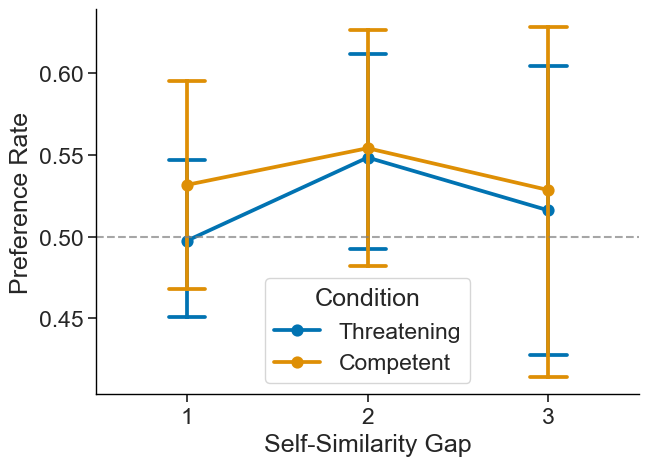

In [8]:
# 5.1 Plot
plt.figure(figsize=(7, 5))
sns.pointplot(
    data=df,
    x="simDiff",
    y="chosen",
    hue="Condition",
    errorbar=("ci", 95),
    # dodge=True,
    capsize=0.2
)
# plt.title("Preference Rate by Surplus Features and Condition")
plt.xlabel("Self-Similarity Gap")
plt.ylabel("Preference Rate")
plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)

sns.despine()
fig_path = os.path.join("attribute_figures", "pointplot_chosen_vs_simDiff_condition.png")
plt.savefig(fig_path, dpi=600, bbox_inches="tight")
print(f"Plot saved to {fig_path}")

plt.show()

FacetGrid figure saved to attribute_figures/pointplot_chosen_vs_simDiff_condition.png


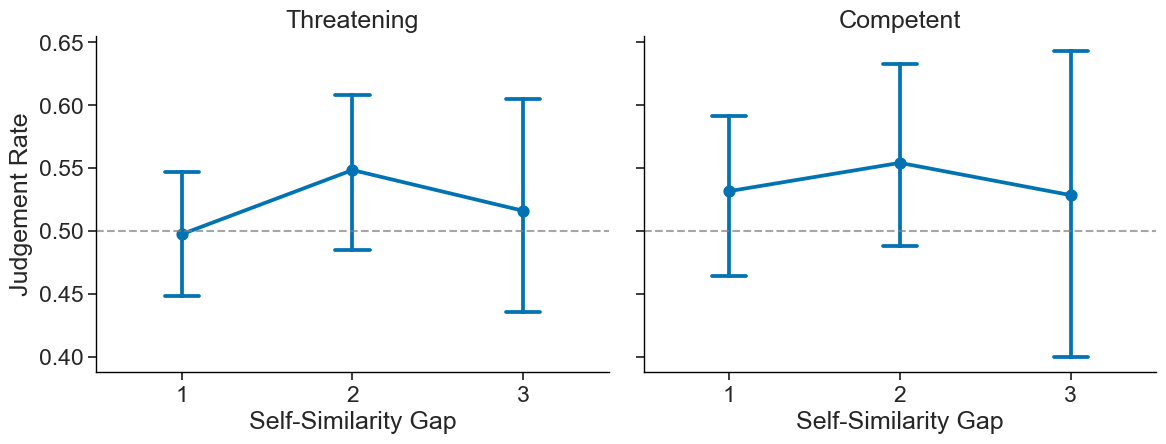

In [9]:

# 5.1 Plot — FacetGrid per Condition
g = sns.FacetGrid(
    data=df,
    col="Condition",
    sharey=True,
    sharex=True,
    margin_titles=True,
    height=5,
    aspect=1.2
)

def facet_pointplot(data, x, y, **kwargs):
    sns.pointplot(
        data=data,
        x=x,
        y=y,
        errorbar=("ci", 95),
        capsize=0.2,
        **kwargs
    )
    plt.axhline(0.5, linestyle="--", color="gray", alpha=0.7)



g.map_dataframe(facet_pointplot, x="simDiff", y="chosen")
g.set_axis_labels("Self-Similarity Gap", "Judgement Rate")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.85)

facet_fig_path = os.path.join("attribute_figures", "pointplot_chosen_vs_simDiff_condition.png")
plt.savefig(facet_fig_path, dpi=600, bbox_inches="tight")
print(f"FacetGrid figure saved to {facet_fig_path}")

plt.show()

### 5.2 Table for (simDiff, Condition)

In [10]:
grouped_cond = df.groupby(["simDiff", "Condition"])["chosen"]

rows = []
for (sd, cond), subset in grouped_cond:
    mean_val, ci_lower, ci_upper = bootstrap_ci(subset, n_boot=5000, ci=95)
    rows.append({
        "Self-Similarity Gap": sd,
        "Condition": cond,
        "Preference Rate": mean_val,
        "CI Lower": ci_lower,
        "CI Upper": ci_upper
    })

df_table_cond = pd.DataFrame(rows).sort_values(
    ["Self-Similarity Gap", "Condition"]
).reset_index(drop=True)

df_table_cond

,Self-Similarity Gap,Condition,Preference Rate,CI Lower,CI Upper
0,1,Competent,0.531746,0.472222,0.595238
1,1,Threatening,0.497537,0.448276,0.546798
2,2,Competent,0.554217,0.475904,0.626506
3,2,Threatening,0.548507,0.488806,0.608209
4,3,Competent,0.528571,0.414286,0.642857
5,3,Threatening,0.516129,0.427419,0.604839


In [11]:
table_filename = os.path.join("attribute_tables", "table_chosen_vs_simDiff_condition.md")
with open(table_filename, "w", encoding="utf-8") as f:
    f.write("| Self-Similarity Gap | Condition            | Preference Rate | 95% CI (Lower) | 95% CI (Upper) |\n")
    f.write("|:-----------------------:|:--------------------:|---------------:|---------------:|---------------:|\n")

    for _, row in df_table_cond.iterrows():
        ssd = str(int(row["Self-Similarity Gap"]))
        cond = row["Condition"]
        mean_str = f"{row['Preference Rate']:.3f}"
        ci_low_str = f"{row['CI Lower']:.3f}"
        ci_up_str = f"{row['CI Upper']:.3f}"

        f.write(f"| {ssd} | {cond} | {mean_str} | {ci_low_str} | {ci_up_str} |\n")

    f.write("\n")
    f.write(": Probability of selecting the more-similar player by similarity difference and Condition. {#tbl-condition}\n")

print(f"Markdown table saved to {table_filename}")

Markdown table saved to attribute_tables/table_chosen_vs_simDiff_condition.md


## 6. Create a 2×2 Facet Grid (Task × Condition)

Instead of four separate figures, we can also arrange `(Task × Condition)`
into a single 2×2 grid using `sns.FacetGrid`. Each subplot is then generated
via `map_dataframe` passing in a pointplot or an equivalent approach.

FacetGrid figure saved to attribute_figures/facetgrid_chosen_vs_simDiff_Task_Condition.png


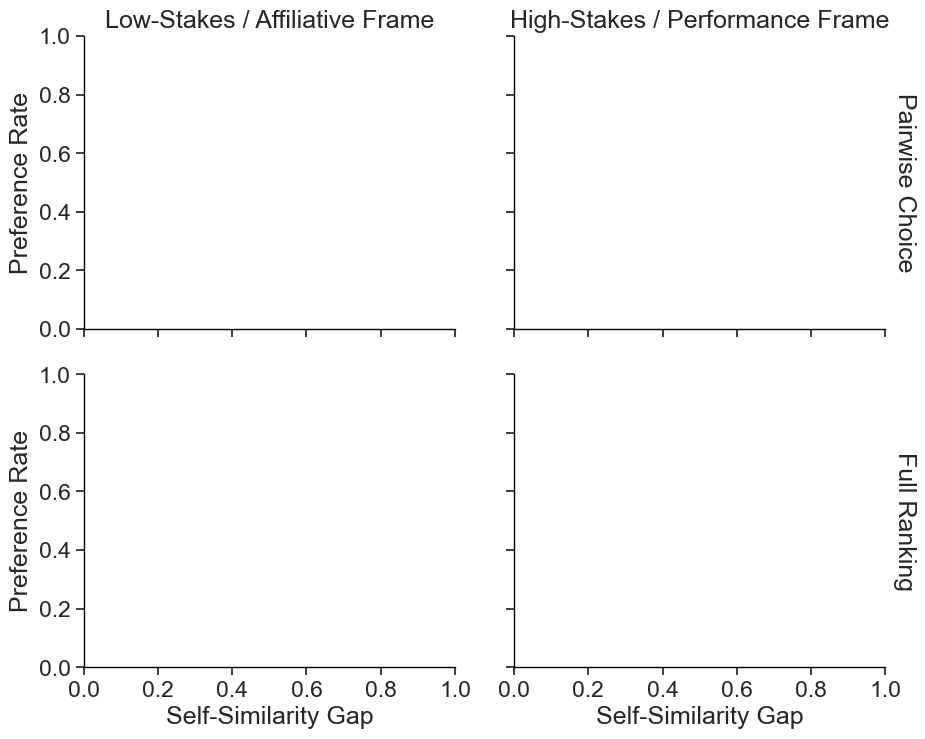

In [12]:
import numpy as np

# Make sure Task and Condition are categorical with the order you want:
df["Task"] = pd.Categorical(
    df["Task"], 
    categories=["Pairwise Choice", "Full Ranking"], 
    ordered=True
)
df["Condition"] = pd.Categorical(
    df["Condition"], 
    categories=[
        "Low-Stakes / Affiliative Frame", 
        "High-Stakes / Performance Frame"
    ], 
    ordered=True
)

# Create the FacetGrid: row ~ Task, col ~ Condition
g = sns.FacetGrid(
    data=df, 
    row="Task",
    col="Condition",
    margin_titles=True,      # moves the facet labels to margins (handy for 2×2)
    sharey=True,            # let all subplots share the same y-axis
    sharex=True,            # let all subplots share the same x-axis
    height=4,               # adjust height of each subplot
    aspect=1.2              # adjust width (aspect ratio)
)

# We'll define a small plotting function that calls sns.pointplot
def facet_pointplot(data, x, y, **kwargs):
    """
    A helper function for map_dataframe that calls seaborn.pointplot.
    We pass 'errorbar' and 'capsize' arguments here, or via kwargs.
    """
    sns.pointplot(
        data=data,
        x=x,
        y=y,
        errorbar=("ci", 95),
        dodge=False,
        capsize=0.2,
        # We can omit hue in the facet approach, or pass one if you had a third variable
        **kwargs
    )
    # Optional horizontal line at 0.5
    plt.axhline(0.5, color="gray", linestyle="--", alpha=0.7)

# Now map our custom function onto the grid
g.map_dataframe(
    facet_pointplot, 
    x="simDiff", 
    y="chosen"
)

# Optionally tweak labels or titles
# Using set_axis_labels for main x/y axis:
g.set_axis_labels(
    x_var="Self-Similarity Gap", 
    y_var="Preference Rate"
)

# Using set_titles to incorporate row/col variables:
# {row_name} will be replaced with Task, {col_name} with Condition
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove the top/right spines
# for ax in g.axes.flatten():
#     sns.despine(ax=ax, trim=True)

# Adjust layout
g.fig.subplots_adjust(top=0.90)
# g.fig.suptitle("Preference Rate by Surplus Features (Task × Condition)", fontsize=14)

# Save figure
facet_fig_path = os.path.join("attribute_figures", "facetgrid_chosen_vs_simDiff_Task_Condition.png")
plt.savefig(facet_fig_path, dpi=300, bbox_inches="tight")
print(f"FacetGrid figure saved to {facet_fig_path}")

plt.show()

### Table for (simDiff, Task, Condition)

In [13]:
grouped_ttc = df.groupby(["simDiff", "Task", "Condition"])["chosen"]

rows = []
for (sd, ttype, cond), subset in grouped_ttc:
    mean_val, ci_lower, ci_upper = bootstrap_ci(subset, n_boot=5000, ci=95)
    rows.append({
        "Self-Similarity Gap": sd,
        "Task Type": ttype,
        "Condition": cond,
        "Preference Rate": mean_val,
        "CI Lower": ci_lower,
        "CI Upper": ci_upper
    })

df_table_ttc = pd.DataFrame(rows).sort_values(
    ["Self-Similarity Gap", "Task Type", "Condition"]
).reset_index(drop=True)

df_table_ttc

/var/folders/7n/m1dxq2r12b77t0c09mty9kn00000gn/T/ipykernel_99524/2185975976.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_ttc = df.groupby(["simDiff", "Task", "Condition"])["chosen"]


KeyError: 'Self-Similarity Gap'

In [ ]:
table_filename = os.path.join("attribute_tables", "table_chosen_vs_simDiff_task_cond.md")
with open(table_filename, "w", encoding="utf-8") as f:
    f.write("| Self-Similarity Gap | Task Type         | Condition            | Preference Rate | 95% CI (Lower) | 95% CI (Upper) |\n")
    f.write("|:-----------------------:|:-----------------:|:--------------------:|---------------:|---------------:|---------------:|\n")

    for _, row in df_table_ttc.iterrows():
        ssd = str(int(row["Self-Similarity Gap"]))
        ttype = row["Task Type"]
        cond = row["Condition"]
        mean_str = f"{row['Preference Rate']:.3f}"
        ci_low_str = f"{row['CI Lower']:.3f}"
        ci_up_str = f"{row['CI Upper']:.3f}"

        f.write(f"| {ssd} | {ttype} | {cond} | {mean_str} | {ci_low_str} | {ci_up_str} |\n")

    f.write("\n")
    f.write(": Probability of selecting the more-similar player by similarity difference, Task Type, and Condition. {#tbl-taskcond}\n")

print(f"Markdown table saved to {table_filename}")

**Done!**  
You now have:
1. **Three “factorial” plots**: 
   - By Task Type
   - By Condition
   - By both (via four separate subplots).
2. **Three matching Markdown tables** in `tables/`.

Each uses more descriptive labels than the original all-lowercase or underscored names.